# Lab 8: Part A: Multiple Regression
Build a Regression model to forecast the exact number of product units
demanded per store each month.

dataset: https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data?select=train.csv

In [82]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

pd.set_option("display.max_columns", None)

DATA_DIR = Path("/content")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"

### Load the Dataset

In [44]:
train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print("Training shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
print("Sample submission shape:", sample_submission.shape)

Training shape: (913000, 4)
Test shape: (45000, 4)
Sample submission shape: (45000, 2)


### First 5 Rows

In [45]:
train_raw.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [46]:
train_raw.tail()

,date,store,item,sales
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62
912999,2017-12-31,10,50,82


In [47]:
rows, columns = train_raw.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 913000
Number of columns: 4


In [48]:
print(train_raw.columns.tolist())

['date', 'store', 'item', 'sales']


In [49]:
train_raw.dtypes

,0
date,object
store,int64
item,int64
sales,int64


### Dataset Information

In [50]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


### Missing Values

In [51]:
missing_values = train_raw.isnull().sum().sort_values(ascending=False)
missing_values

,0
date,0
store,0
item,0
sales,0


### Duplicate Records

In [52]:
duplicate_count = train_raw.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


### Exploratory Data Analysis

### Numerical and Categorical Variables

In [53]:
eda_df = train_raw.copy()
eda_df["date"] = pd.to_datetime(eda_df["date"])

numerical_variables = ["sales"]
categorical_variables = ["store", "item"]
temporal_variables = ["date"]

print("Numerical variables:", numerical_variables)
print("Categorical variables:", categorical_variables)
print("Temporal variable:", temporal_variables)

Numerical variables: ['sales']
Categorical variables: ['store', 'item']
Temporal variable: ['date']


### Daily Sales Distribution

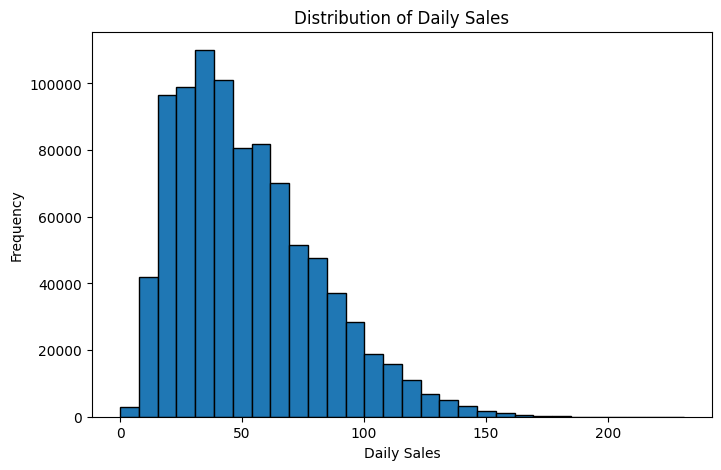

In [54]:
plt.figure(figsize=(8, 5))
plt.hist(train_raw["sales"], bins=30, edgecolor="black")
plt.title("Distribution of Daily Sales")
plt.xlabel("Daily Sales")
plt.ylabel("Frequency")
plt.show()

### Sales Distribution by Store

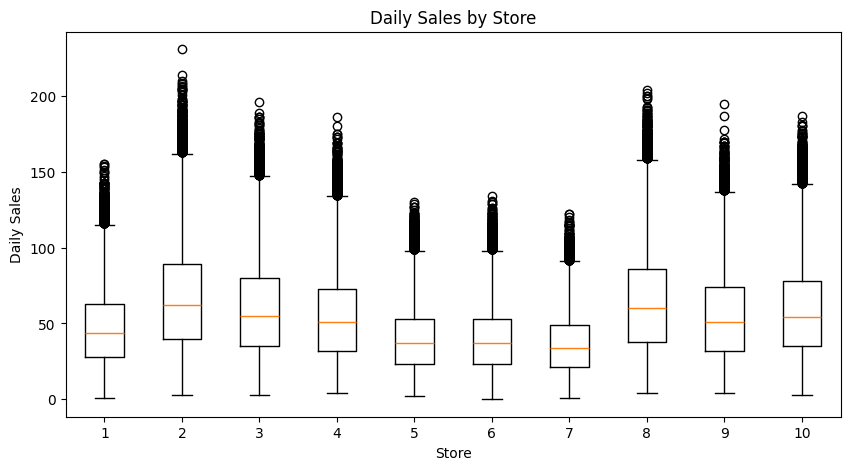

In [55]:
plt.figure(figsize=(10, 5))
plt.boxplot([train_raw.loc[train_raw["store"] == s, "sales"] for s in sorted(train_raw["store"].unique())], labels=sorted(train_raw["store"].unique()))
plt.title("Daily Sales by Store")
plt.xlabel("Store")
plt.ylabel("Daily Sales")
plt.show()

### Sales Distribution by Item

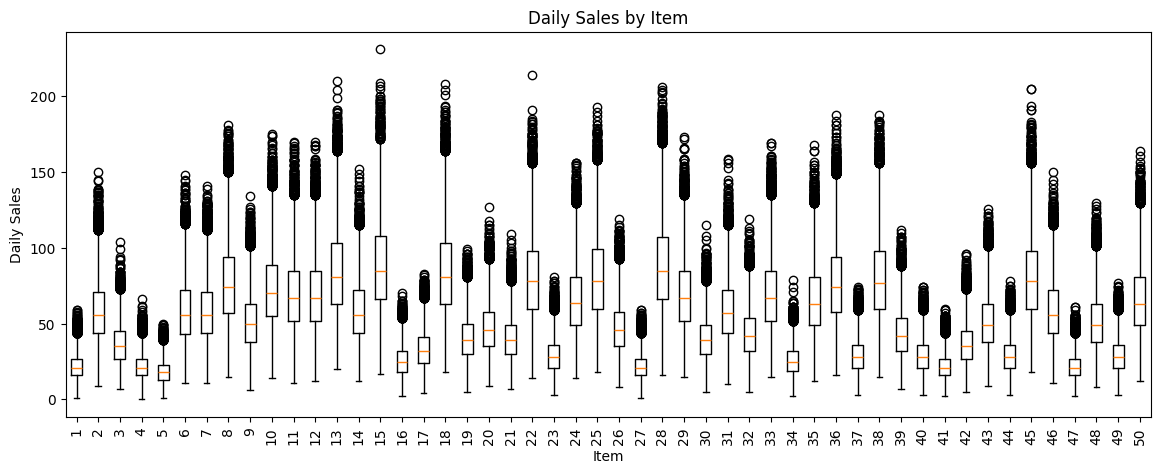

In [56]:
plt.figure(figsize=(14, 5))
plt.boxplot([train_raw.loc[train_raw["item"] == i, "sales"] for i in sorted(train_raw["item"].unique())], labels=sorted(train_raw["item"].unique()))
plt.title("Daily Sales by Item")
plt.xlabel("Item")
plt.ylabel("Daily Sales")
plt.xticks(rotation=90)
plt.show()

### Scatter Plot: Item vs Daily Sales

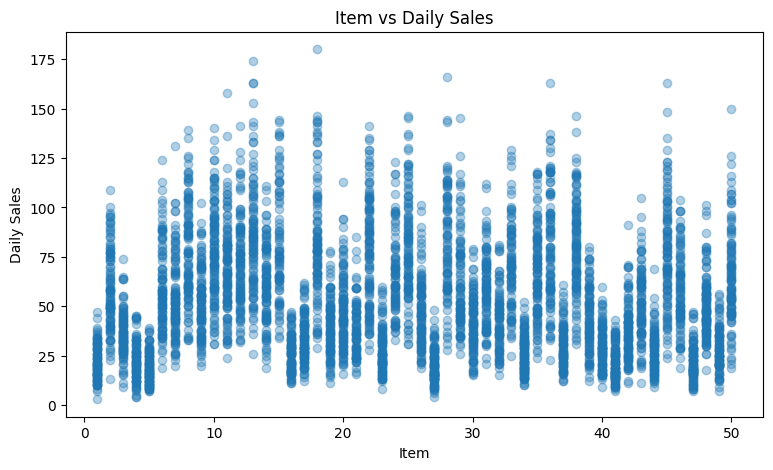

In [57]:
scatter_sample = train_raw.sample(min(5000, len(train_raw)), random_state=42)

plt.figure(figsize=(9, 5))
plt.scatter(scatter_sample["item"], scatter_sample["sales"], alpha=0.35)
plt.title("Item vs Daily Sales")
plt.xlabel("Item")
plt.ylabel("Daily Sales")
plt.show()

### Scatter Plot: Store vs Daily Sales

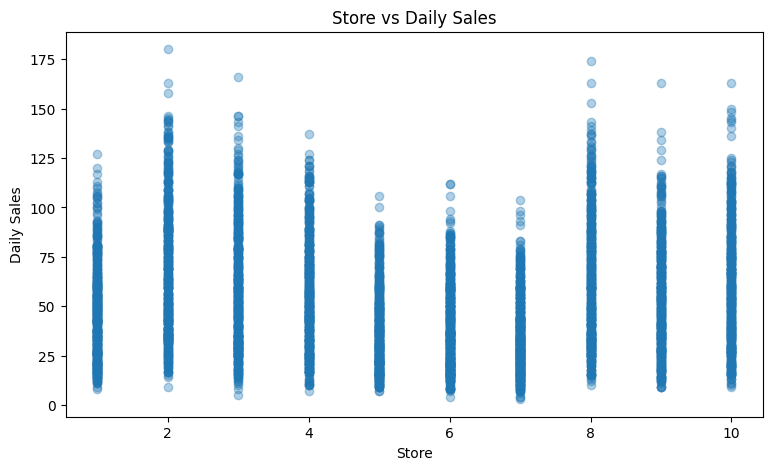

In [58]:
plt.figure(figsize=(9, 5))
plt.scatter(scatter_sample["store"], scatter_sample["sales"], alpha=0.35)
plt.title("Store vs Daily Sales")
plt.xlabel("Store")
plt.ylabel("Daily Sales")
plt.show()

### Data Pre-processing

### Prepare the Daily Data

In [59]:
df = train_raw.copy()

df["date"] = pd.to_datetime(df["date"])

required_columns = ["date", "store", "item", "sales"]
df = df.dropna(subset=required_columns)
df = df.drop_duplicates()

df["store"] = df["store"].astype(str)
df["item"] = df["item"].astype(str)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (913000, 4)


### Create Monthly Demand

In [60]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter

monthly_df = (
    df.groupby(["year", "month", "quarter", "store", "item"], as_index=False)["sales"]
      .sum()
      .rename(columns={"sales": "monthly_demand"})
)

monthly_df["date"] = pd.to_datetime(
    monthly_df["year"].astype(str) + "-" + monthly_df["month"].astype(str) + "-01"
)

monthly_df = monthly_df.sort_values(["date", "store", "item"]).reset_index(drop=True)

start_year = monthly_df["year"].min()
monthly_df["time_index"] = (
    (monthly_df["year"] - start_year) * 12 + monthly_df["month"]
)

monthly_df.head()

,year,month,quarter,store,item,monthly_demand,date,time_index
0,2013,1,1,1,1,328,2013-01-01,1
1,2013,1,1,1,10,1121,2013-01-01,1
2,2013,1,1,1,11,1093,2013-01-01,1
3,2013,1,1,1,12,1128,2013-01-01,1
4,2013,1,1,1,13,1308,2013-01-01,1


### Monthly Dataset Overview

In [61]:
print("Monthly dataset shape:", monthly_df.shape)
print("Missing values:\n")
print(monthly_df.isnull().sum())
print("\nDuplicate records:", monthly_df.duplicated().sum())

Monthly dataset shape: (30000, 8)
Missing values:

year              0
month             0
quarter           0
store             0
item              0
monthly_demand    0
date              0
time_index        0
dtype: int64

Duplicate records: 0


### Monthly Demand Distribution

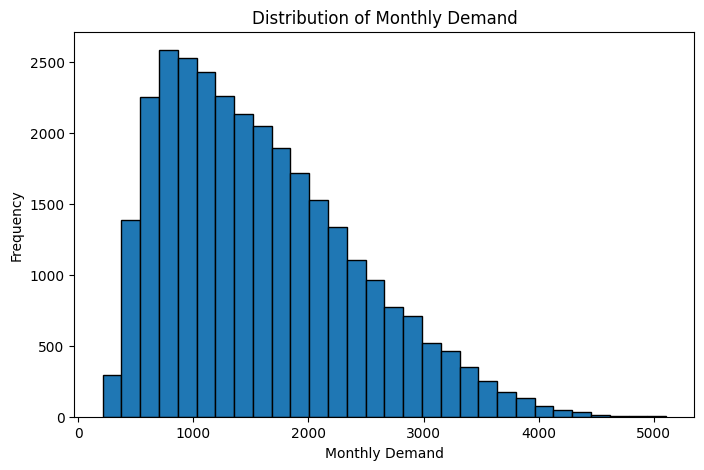

In [62]:
plt.figure(figsize=(8, 5))
plt.hist(monthly_df["monthly_demand"], bins=30, edgecolor="black")
plt.title("Distribution of Monthly Demand")
plt.xlabel("Monthly Demand")
plt.ylabel("Frequency")
plt.show()

### Monthly Demand Box Plot by Store

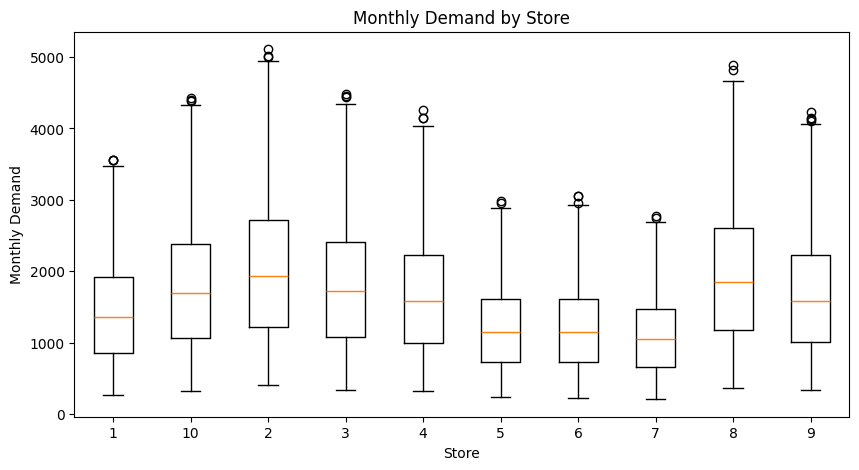

In [63]:
plt.figure(figsize=(10, 5))
plt.boxplot([monthly_df.loc[monthly_df["store"] == s, "monthly_demand"] for s in sorted(monthly_df["store"].unique())], labels=sorted(monthly_df["store"].unique()))
plt.title("Monthly Demand by Store")
plt.xlabel("Store")
plt.ylabel("Monthly Demand")
plt.show()

### Monthly Demand Scatter Plot

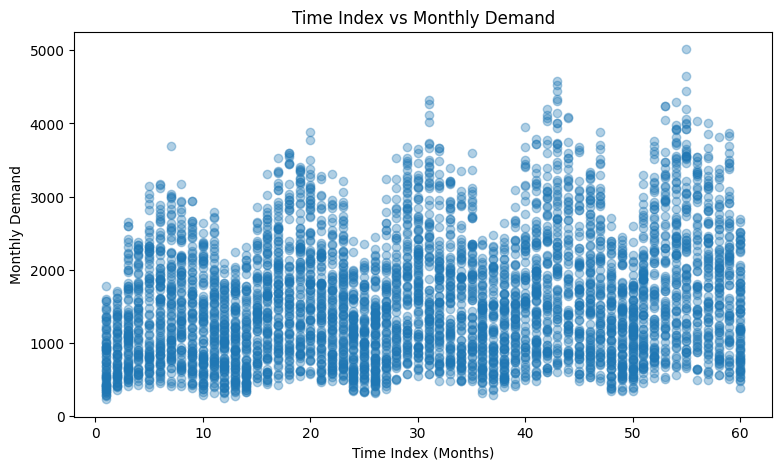

In [83]:
scatter_monthly = monthly_df.sample(min(5000, len(monthly_df)), random_state=42)

plt.figure(figsize=(9, 5))
plt.scatter(scatter_monthly["time_index"], scatter_monthly["monthly_demand"], alpha=0.35)
plt.title("Time Index vs Monthly Demand")
plt.xlabel("Time Index (Months)")
plt.ylabel("Monthly Demand")
plt.show()

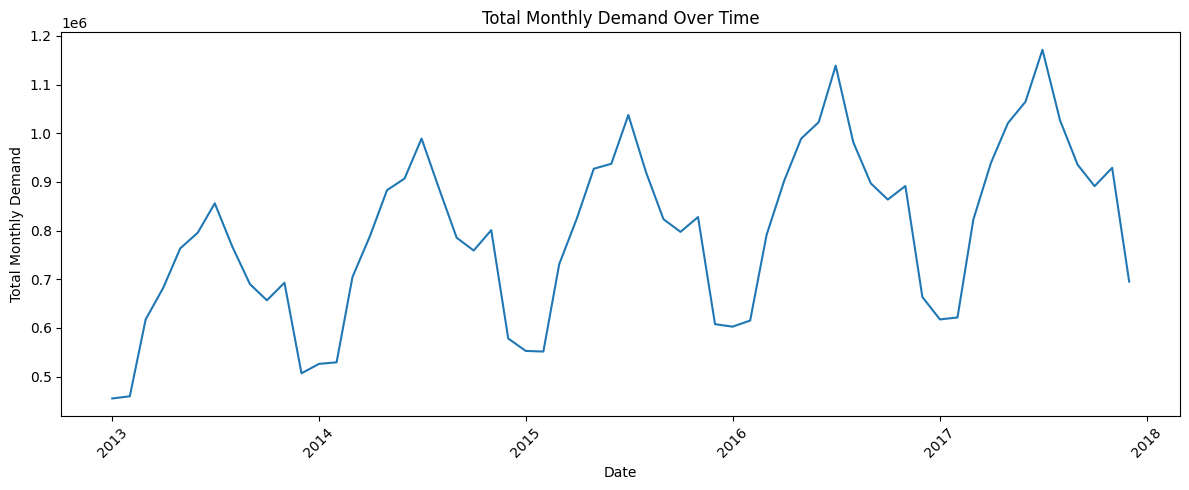

In [84]:

monthly_trend = (
    monthly_df.groupby("date", as_index=False)["monthly_demand"]
    .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_trend["date"], monthly_trend["monthly_demand"])
plt.title("Total Monthly Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Monthly Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Identify Model Variables

In [65]:
target = "monthly_demand"

feature_columns = [
    "year",
    "month",
    "quarter",
    "time_index",
    "store",
    "item"
]

numerical_features = [
    "year",
    "month",
    "quarter",
    "time_index"
]

categorical_features = [
    "store",
    "item"
]

X = monthly_df[feature_columns]
y = monthly_df[target]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target:", target)

Numerical features: ['year', 'month', 'quarter', 'time_index']
Categorical features: ['store', 'item']
Target: monthly_demand


### Convert Categorical Variables into Numerical Form

In [66]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Categorical variables will be one-hot encoded inside each model pipeline.")


Categorical variables will be one-hot encoded inside each model pipeline.


### Correlation Analysis

                 year  month  quarter  time_index  monthly_demand
year            1.000 -0.000   -0.000       0.980           0.195
month          -0.000  1.000    0.972       0.199           0.106
quarter        -0.000  0.972    1.000       0.194           0.115
time_index      0.980  0.199    0.194       1.000           0.212
monthly_demand  0.195  0.106    0.115       0.212           1.000


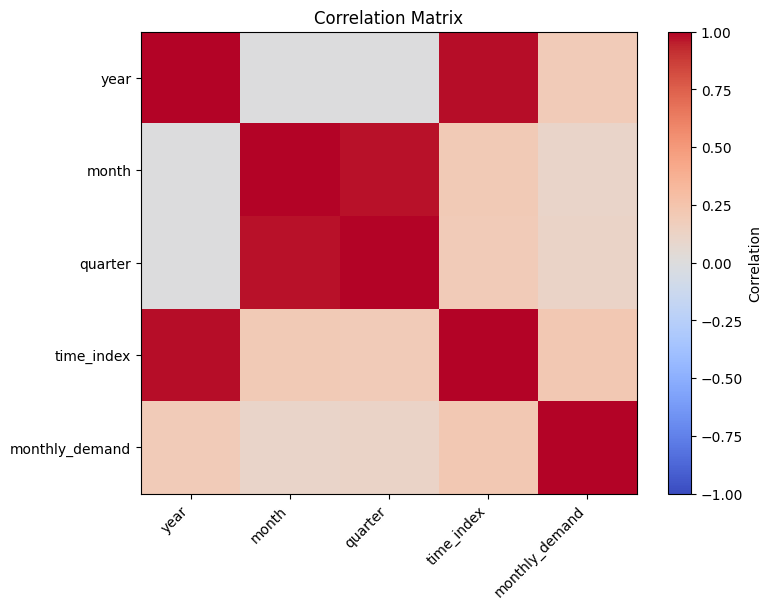

In [67]:
correlation_columns = numerical_features + [target]
correlation_matrix = monthly_df[correlation_columns].corr()

print(correlation_matrix.round(3))

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Correlation Matrix")
plt.show()

### Correlation with Monthly Demand

In [68]:
correlation_with_target = (
    correlation_matrix[target]
    .sort_values(ascending=False)
    .to_frame("correlation")
)

correlation_with_target

,correlation
monthly_demand,1.000000
time_index,0.211908
year,0.194677
quarter,0.114868
month,0.106041


### Covariance Analysis

                   year    month  quarter  time_index  monthly_demand
year              2.000    0.000     0.00      24.001         226.897
month             0.000   11.917     3.75      11.917         301.682
quarter           0.000    3.750     1.25       3.750         105.840
time_index       24.001   11.917     3.75     299.927        3024.441
monthly_demand  226.897  301.682   105.84    3024.441      679173.065


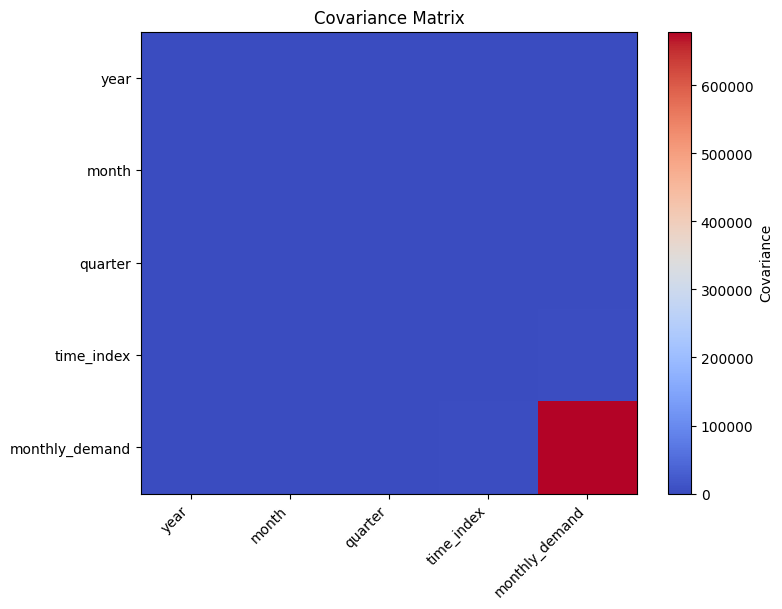

In [69]:
covariance_matrix = monthly_df[correlation_columns].cov()

print(covariance_matrix.round(3))

plt.figure(figsize=(8, 6))
plt.imshow(covariance_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Covariance")
plt.xticks(range(len(covariance_matrix.columns)), covariance_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(covariance_matrix.index)), covariance_matrix.index)
plt.title("Covariance Matrix")
plt.show()

### Train-Test Split

In [70]:
split_date = pd.Timestamp("2017-01-01")

train_data = monthly_df[monthly_df["date"] < split_date].copy()
test_data = monthly_df[monthly_df["date"] >= split_date].copy()

X_train = train_data[feature_columns]
y_train = train_data[target]

X_test = test_data[feature_columns]
y_test = test_data[target]

print("Training period:", train_data["date"].min().date(), "to", train_data["date"].max().date())
print("Testing period:", test_data["date"].min().date(), "to", test_data["date"].max().date())
print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

Training period: 2013-01-01 to 2016-12-01
Testing period: 2017-01-01 to 2017-12-01
Training rows: 24000
Testing rows: 6000


### Multiple Linear Regression

In [71]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_metrics = {
    "Model": "Multiple Linear Regression",
    "MAE": mean_absolute_error(y_test, linear_predictions),
    "MSE": mean_squared_error(y_test, linear_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test, linear_predictions)),
    "R2": r2_score(y_test, linear_predictions)
}

pd.DataFrame([linear_metrics]).round(3)

,Model,MAE,MSE,RMSE,R2
0,Multiple Linear Regression,317.019,165035.846,406.246,0.798


### Ridge Regression

In [72]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10.0))
])

ridge_model.fit(X_train, y_train)
ridge_predictions = ridge_model.predict(X_test)

ridge_metrics = {
    "Model": "Ridge Regression",
    "MAE": mean_absolute_error(y_test, ridge_predictions),
    "MSE": mean_squared_error(y_test, ridge_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test, ridge_predictions)),
    "R2": r2_score(y_test, ridge_predictions)
}

pd.DataFrame([ridge_metrics]).round(3)

,Model,MAE,MSE,RMSE,R2
0,Ridge Regression,320.884,167917.674,409.778,0.794


### Lasso Regression

In [73]:
lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.01, max_iter=10000))
])

lasso_model.fit(X_train, y_train)
lasso_predictions = lasso_model.predict(X_test)

lasso_metrics = {
    "Model": "Lasso Regression",
    "MAE": mean_absolute_error(y_test, lasso_predictions),
    "MSE": mean_squared_error(y_test, lasso_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test, lasso_predictions)),
    "R2": r2_score(y_test, lasso_predictions)
}

pd.DataFrame([lasso_metrics]).round(3)

,Model,MAE,MSE,RMSE,R2
0,Lasso Regression,317.144,165130.102,406.362,0.798


### Decision Tree Regression

In [74]:
tree_numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

tree_categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

tree_preprocessor = ColumnTransformer([
    ("num", tree_numeric_transformer, numerical_features),
    ("cat", tree_categorical_transformer, categorical_features)
])

tree_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeRegressor(max_depth=15, random_state=42))
])

tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)

tree_metrics = {
    "Model": "Decision Tree",
    "MAE": mean_absolute_error(y_test, tree_predictions),
    "MSE": mean_squared_error(y_test, tree_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test, tree_predictions)),
    "R2": r2_score(y_test, tree_predictions)
}

pd.DataFrame([tree_metrics]).round(3)

,Model,MAE,MSE,RMSE,R2
0,Decision Tree,470.399,384815.172,620.335,0.528


### Random Forest Regression

In [75]:
forest_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

forest_model.fit(X_train, y_train)
forest_predictions = forest_model.predict(X_test)

forest_metrics = {
    "Model": "Random Forest",
    "MAE": mean_absolute_error(y_test, forest_predictions),
    "MSE": mean_squared_error(y_test, forest_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test, forest_predictions)),
    "R2": r2_score(y_test, forest_predictions)
}

pd.DataFrame([forest_metrics]).round(3)

,Model,MAE,MSE,RMSE,R2
0,Random Forest,450.38,340539.491,583.558,0.583


### Model Selection

In [76]:
results = pd.DataFrame([
    linear_metrics,
    ridge_metrics,
    lasso_metrics,
    tree_metrics,
    forest_metrics
])

results = results.sort_values("RMSE").reset_index(drop=True)

results.round(3)

,Model,MAE,MSE,RMSE,R2
0,Multiple Linear Regression,317.019,165035.846,406.246,0.798
1,Lasso Regression,317.144,165130.102,406.362,0.798
2,Ridge Regression,320.884,167917.674,409.778,0.794
3,Random Forest,450.380,340539.491,583.558,0.583
4,Decision Tree,470.399,384815.172,620.335,0.528


### Compare Model Performance

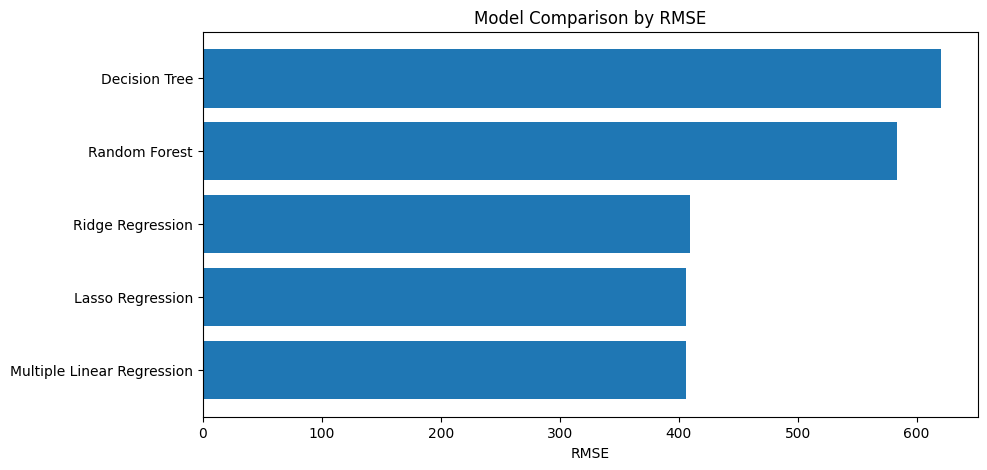

In [77]:
plt.figure(figsize=(10, 5))
plt.barh(results["Model"], results["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("")
plt.show()

### Best Model Predictions

Best model: Multiple Linear Regression


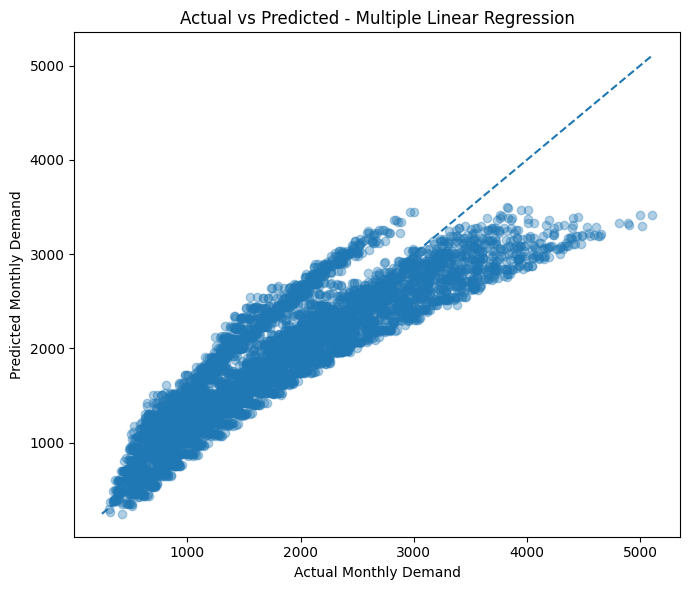

In [78]:
best_model_name = results.loc[0, "Model"]

model_lookup = {
    "Multiple Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

prediction_lookup = {
    "Multiple Linear Regression": linear_predictions,
    "Ridge Regression": ridge_predictions,
    "Lasso Regression": lasso_predictions,
    "Decision Tree": tree_predictions,
    "Random Forest": forest_predictions
}

best_model = model_lookup[best_model_name]
best_predictions = prediction_lookup[best_model_name]

print("Best model:", best_model_name)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_predictions, alpha=0.35)
plt.xlabel("Actual Monthly Demand")
plt.ylabel("Predicted Monthly Demand")
plt.title(f"Actual vs Predicted - {best_model_name}")

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()

### Save the Best Model using Joblib

In [79]:
# Refit the selected model on all available monthly training data.
best_model.fit(X, y)

model_path = DATA_DIR / "best_monthly_demand_model.joblib"
joblib.dump(best_model, model_path)

print("Best model saved to:", model_path)

Best model saved to: /content/best_monthly_demand_model.joblib


### Forecast Monthly Demand for the Kaggle Test Period

In [80]:
future_df = test_raw.copy()
future_df["date"] = pd.to_datetime(future_df["date"])

future_df["year"] = future_df["date"].dt.year
future_df["month"] = future_df["date"].dt.month
future_df["quarter"] = future_df["date"].dt.quarter

future_df["store"] = future_df["store"].astype(str)
future_df["item"] = future_df["item"].astype(str)

future_monthly = (
    future_df[["year", "month", "quarter", "store", "item"]]
    .drop_duplicates()
    .sort_values(["year", "month", "store", "item"])
    .reset_index(drop=True)
)

future_monthly["date"] = pd.to_datetime(
    future_monthly["year"].astype(str) + "-" +
    future_monthly["month"].astype(str) + "-01"
)

future_monthly["time_index"] = (
    (future_monthly["year"] - start_year) * 12 + future_monthly["month"]
)

future_features = future_monthly[feature_columns]

future_monthly["predicted_monthly_demand"] = best_model.predict(future_features)
future_monthly["predicted_monthly_demand"] = (
    future_monthly["predicted_monthly_demand"]
    .clip(lower=0)
    .round()
    .astype(int)
)

forecast_path = DATA_DIR / "monthly_demand_forecast.csv"
future_monthly.to_csv(forecast_path, index=False)

future_monthly.head()

,year,month,quarter,store,item,date,time_index,predicted_monthly_demand
0,2018,1,1,1,1,2018-01-01,61,754
1,2018,1,1,1,10,2018-01-01,61,2314
2,2018,1,1,1,11,2018-01-01,61,2205
3,2018,1,1,1,12,2018-01-01,61,2205
4,2018,1,1,1,13,2018-01-01,61,2652


### Final Forecast Summary

Forecast rows: 1500
Forecast period: 2018-01-01 to 2018-03-01
Forecast file: /content/monthly_demand_forecast.csv


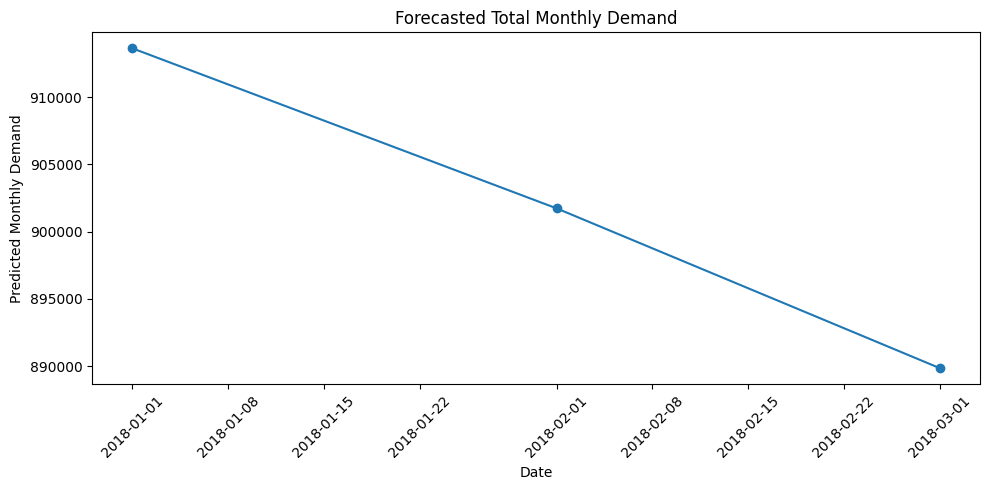

,year,month,quarter,store,item,date,time_index,predicted_monthly_demand
0,2018,1,1,1,1,2018-01-01,61,754
1,2018,1,1,1,10,2018-01-01,61,2314
2,2018,1,1,1,11,2018-01-01,61,2205
3,2018,1,1,1,12,2018-01-01,61,2205
4,2018,1,1,1,13,2018-01-01,61,2652
5,2018,1,1,1,14,2018-01-01,61,1871
6,2018,1,1,1,15,2018-01-01,61,2765
7,2018,1,1,1,16,2018-01-01,61,866
8,2018,1,1,1,17,2018-01-01,61,1090
9,2018,1,1,1,18,2018-01-01,61,2650


In [81]:
print("Forecast rows:", len(future_monthly))
print(
    "Forecast period:",
    future_monthly["date"].min().date(),
    "to",
    future_monthly["date"].max().date()
)
print("Forecast file:", forecast_path)

forecast_trend = (
    future_monthly.groupby("date", as_index=False)["predicted_monthly_demand"]
    .sum()
)

plt.figure(figsize=(10, 5))
plt.plot(
    forecast_trend["date"],
    forecast_trend["predicted_monthly_demand"],
    marker="o"
)
plt.title("Forecasted Total Monthly Demand")
plt.xlabel("Date")
plt.ylabel("Predicted Monthly Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

future_monthly.head(10)